In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [15]:
#"How effectively is the company acquiring new customers (or converting competitors) across different global markets, and
#  how do discount strategies and sales channels impact the likelihood of those customers returning their products?"

In [16]:
df = pd.read_csv(r"D:\machine learning project python\apple eda or machine learnig\apple_global_sales_dataset.csv")
df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,ARS,907.0,134344.84,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,ARS,907.0,115597.15,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,ARS,907.0,1066341.76,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3506044.78,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1952780.07,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Data columns (total 27 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   sale_id                 11500 non-null  object 
 1   sale_date               11500 non-null  object 
 2   year                    11500 non-null  int64  
 3   quarter                 11500 non-null  object 
 4   month                   11500 non-null  object 
 5   country                 11500 non-null  object 
 6   region                  11500 non-null  object 
 7   city                    11500 non-null  object 
 8   product_name            11500 non-null  object 
 9   category                11500 non-null  object 
 10  storage                 6696 non-null   object 
 11  color                   11500 non-null  object 
 12  unit_price_usd          11500 non-null  float64
 13  discount_pct            11500 non-null  int64  
 14  units_sold              11500 non-null

In [18]:
df.describe()

,year,unit_price_usd,discount_pct,units_sold,discounted_price_usd,revenue_usd,fx_rate_to_usd,revenue_local_currency,customer_rating
count,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,11500.000000,1.150000e+04,8140.000000
mean,2022.997304,807.851191,3.841565,2.023478,777.365478,1568.319065,1029.406647,1.464369e+06,4.000934
std,0.821747,1112.437595,4.783161,1.443599,1072.915122,2839.759822,4072.334957,9.941160e+06,0.575192
min,2022.000000,26.690000,0.000000,1.000000,22.730000,23.000000,0.790000,2.130000e+01,3.000000
25%,2022.000000,180.147500,0.000000,1.000000,178.297500,305.740000,0.920000,1.041693e+03,3.500000
50%,2023.000000,593.905000,2.000000,1.000000,573.420000,833.040000,7.240000,6.164160e+03,4.000000
75%,2024.000000,958.387500,7.000000,3.000000,928.567500,1748.360000,91.500000,7.471653e+04,4.500000
max,2024.000000,7551.010000,15.000000,8.000000,7551.010000,59529.520000,24500.000000,5.075175e+08,5.000000


In [19]:
df.shape

(11500, 27)

In [8]:
df.columns

Index(['sale_id', 'sale_date', 'year', 'quarter', 'month', 'country', 'region',
       'city', 'product_name', 'category', 'storage', 'color',
       'unit_price_usd', 'discount_pct', 'units_sold', 'discounted_price_usd',
       'revenue_usd', 'currency', 'fx_rate_to_usd', 'revenue_local_currency',
       'sales_channel', 'payment_method', 'customer_segment',
       'customer_age_group', 'previous_device_os', 'customer_rating',
       'return_status'],
      dtype='object')

In [20]:
df.head()

,sale_id,sale_date,year,quarter,month,country,region,city,product_name,category,...,currency,fx_rate_to_usd,revenue_local_currency,sales_channel,payment_method,customer_segment,customer_age_group,previous_device_os,customer_rating,return_status
0,APPL-00000001,2022-01-03,2022,Q1,January,Argentina,South America,Buenos Aires,AirPods (3rd Gen),AirPods,...,ARS,907.0,134344.84,Third-Party Retailer,Cash,Government,45–54,NaN,4.1,Kept
1,APPL-00000002,2022-01-04,2022,Q1,January,Argentina,South America,Buenos Aires,USB-C Woven Charge Cable,Accessories,...,ARS,907.0,115597.15,Authorized Reseller,Debit Card,Business,45–54,NaN,4.8,Kept
2,APPL-00000003,2022-05-18,2022,Q2,May,Argentina,South America,Buenos Aires,Apple Watch Series 8,Apple Watch,...,ARS,907.0,1066341.76,Corporate / B2B,Credit Card,Individual,18–24,NaN,4.3,Kept
3,APPL-00000004,2022-05-23,2022,Q2,May,Argentina,South America,Buenos Aires,MacBook Pro 14-inch (M3),Mac,...,ARS,907.0,3506044.78,Carrier Store,Credit Card,Education,45–54,NaN,NaN,Kept
4,APPL-00000005,2022-07-13,2022,Q3,July,Argentina,South America,Buenos Aires,Apple Watch Ultra 2,Apple Watch,...,ARS,907.0,1952780.07,Apple Store,Net Banking,Education,18–24,NaN,NaN,Kept


In [21]:
df.isnull().sum()

sale_id                      0
sale_date                    0
year                         0
quarter                      0
month                        0
country                      0
region                       0
city                         0
product_name                 0
category                     0
storage                   4804
color                        0
unit_price_usd               0
discount_pct                 0
units_sold                   0
discounted_price_usd         0
revenue_usd                  0
currency                     0
fx_rate_to_usd               0
revenue_local_currency       0
sales_channel                0
payment_method               0
customer_segment             0
customer_age_group           0
previous_device_os        8056
customer_rating           3360
return_status                0
dtype: int64

In [22]:
df['customer_rating'] = df['customer_rating'].fillna(df['customer_rating'].median())

In [23]:
df['previous_device_os'] = df['previous_device_os'].replace('N/A', 'UNKNOWN')
df['previous_device_os'] = df['previous_device_os'].ffill()

In [24]:
df['storage'] = df['storage'].replace('N/A', '500 GB')
df['storage'] = df['storage'].ffill()

In [25]:
df.isnull().sum()

sale_id                   0
sale_date                 0
year                      0
quarter                   0
month                     0
country                   0
region                    0
city                      0
product_name              0
category                  0
storage                   3
color                     0
unit_price_usd            0
discount_pct              0
units_sold                0
discounted_price_usd      0
revenue_usd               0
currency                  0
fx_rate_to_usd            0
revenue_local_currency    0
sales_channel             0
payment_method            0
customer_segment          0
customer_age_group        0
previous_device_os        7
customer_rating           0
return_status             0
dtype: int64

In [26]:
new_users = df[df['previous_device_os'] == 'New User']

new_users_by_region = new_users.groupby('region').size().reset_index(name='New_Customers')

print(new_users_by_region)

          region  New_Customers
0         Africa            106
1           Asia            575
2         Europe            665
3    Europe/Asia             46
4    Middle East             75
5  North America            111
6        Oceania            101
7  South America            163


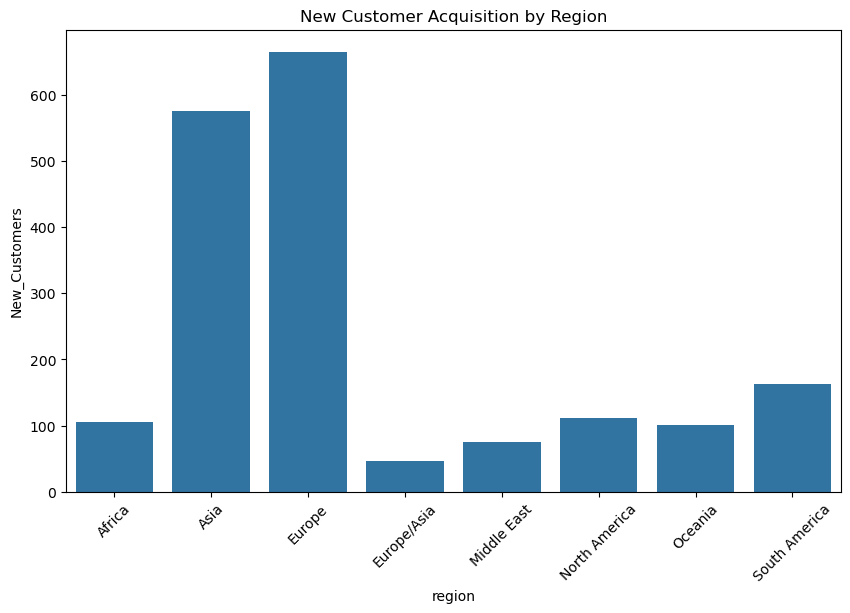

In [27]:


plt.figure(figsize=(10,6))
sns.barplot(x='region', y='New_Customers', data=new_users_by_region)
plt.title("New Customer Acquisition by Region")
plt.xticks(rotation=45)
plt.show()

In [28]:
df['return_status'] = df['return_status'].replace({'Returned':1, 'Kept':0})
df['return_status'] = pd.to_numeric(df['return_status'], errors='coerce')


In [29]:
return_by_discount = df.groupby('discount_pct')['return_status'].mean().reset_index()

print(return_by_discount)

   discount_pct  return_status
0             0       0.083350
1             2       0.090147
2             3       0.085193
3             5       0.068862
4             7       0.067114
5            10       0.083821
6            15       0.083754


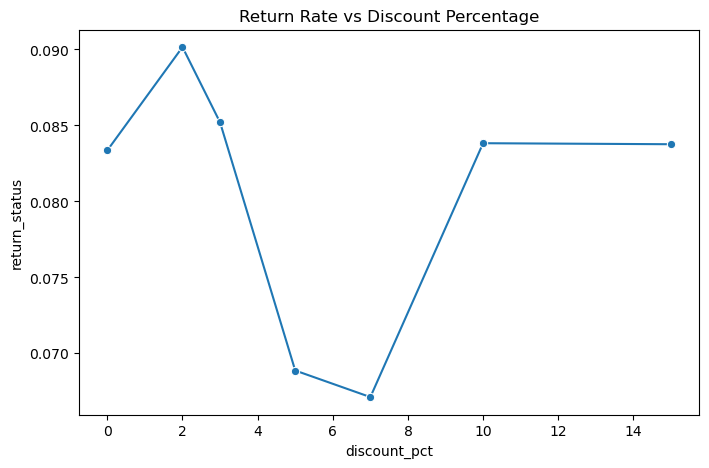

In [30]:
plt.figure(figsize=(8,5))
sns.lineplot(x='discount_pct', y='return_status', data=return_by_discount, marker='o')
plt.title("Return Rate vs Discount Percentage")
plt.show()

In [31]:
return_by_channel = df.groupby('sales_channel')['return_status'].mean().reset_index()

print(return_by_channel)

          sales_channel  return_status
0           Apple Store       0.076419
1   Authorized Reseller       0.087710
2         Carrier Store       0.076419
3       Corporate / B2B       0.079391
4    Online (Apple.com)       0.079245
5  Third-Party Retailer       0.088780


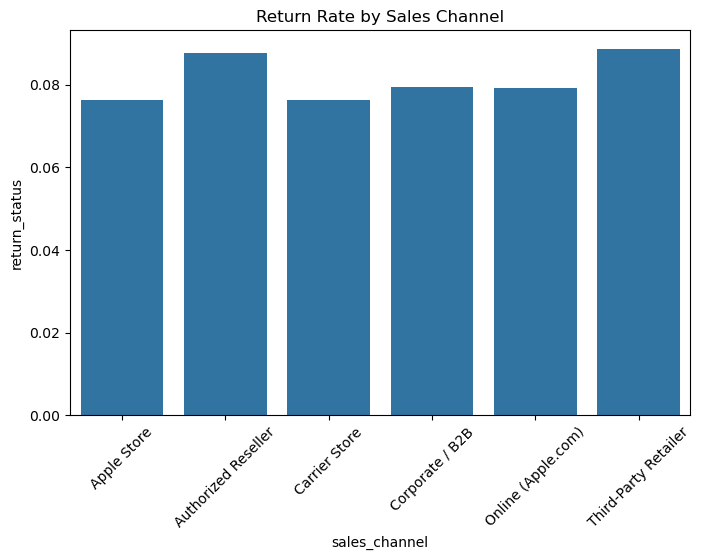

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(x='sales_channel', y='return_status', data=return_by_channel)
plt.title("Return Rate by Sales Channel")
plt.xticks(rotation=45)
plt.show()

In [33]:


df['Revenue_Loss'] = np.where(df['return_status'] == 1, df['revenue_usd'], 0)

revenue_loss_region = df.groupby('region')['Revenue_Loss'].sum().reset_index()

print(revenue_loss_region)

          region  Revenue_Loss
0         Africa     112496.22
1           Asia     440551.99
2         Europe     492830.36
3    Europe/Asia      51429.42
4    Middle East      88065.66
5  North America     130671.18
6        Oceania      61398.07
7  South America     100298.13


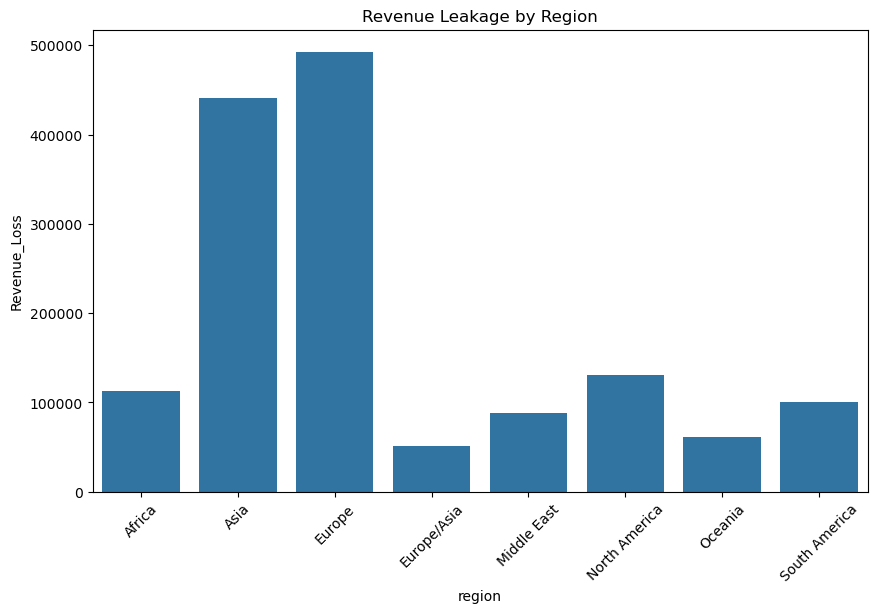

In [34]:
plt.figure(figsize=(10,6))
sns.barplot(x='region', y='Revenue_Loss', data=revenue_loss_region)
plt.title("Revenue Leakage by Region")
plt.xticks(rotation=45)
plt.show()

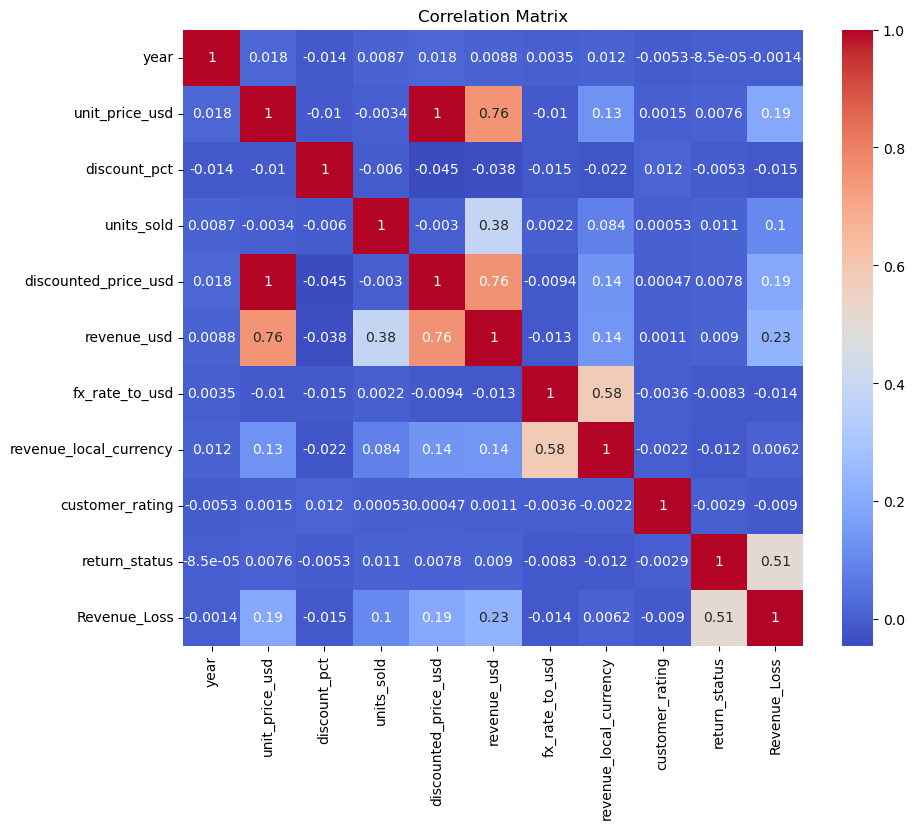

In [35]:
plt.figure(figsize=(10,8))
sns.heatmap(df.select_dtypes(include='number').corr(), 
            annot=True, 
            cmap='coolwarm')

plt.title("Correlation Matrix")
plt.show()

In [36]:
X = df[['discount_pct',
        'customer_rating',
        'unit_price_usd',
        'units_sold',
        'year']]

y = df['revenue_usd']

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [40]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [41]:
pred = model.predict(X_test)

In [42]:
print(pred)

[ 905.65560673  448.95600518  782.31368015 ...  979.01310147 1302.35161005
   90.8404142 ]


In [43]:
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

print("R2 Score:", r2_score(y_test, pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred)))

R2 Score: 0.6760970938857997
RMSE: 1524.1703192590903


In [44]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coeff_df)

           Feature  Coefficient
0     discount_pct   -16.416573
1  customer_rating   -20.309100
2   unit_price_usd     1.963794
3       units_sold   758.336304
4             year   -22.814839


In [45]:
result = pd.DataFrame({
    'Actual_Revenue': y_test.values,
    'Predicted_Revenue': pred
})

print(result.head(10))

   Actual_Revenue  Predicted_Revenue
0          828.91         905.655607
1          594.04         448.956005
2          774.04         782.313680
3          386.96         -10.416179
4         2309.56        2686.731101
5          964.66        1162.884465
6         1828.26        1872.989474
7          168.74        -387.952274
8           39.80        -663.951315
9          604.43         437.084951


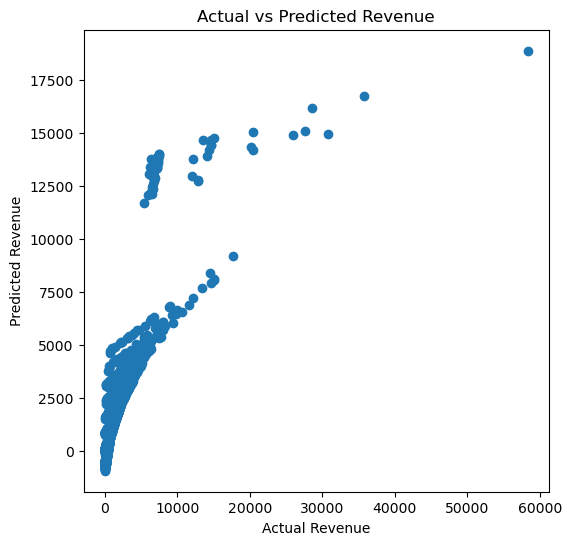

In [46]:


plt.figure(figsize=(6,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")
plt.show()

In [47]:
new_data = [[10, 4.5, 1000, 5,2025]]

prediction = model.predict(new_data)

print("Predicted Revenue:", prediction[0])

Predicted Revenue: 4055.036347759393


c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [49]:


accuracy = model.score(X_test, y_test)

print("Accuracy:", accuracy)

Accuracy: 0.6760970938857997


In [50]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [51]:
rf_pred = rf.predict(X_test)

In [52]:
print("Random Forest R2:", r2_score(y_test, rf_pred))
print("Random Forest RMSE:", np.sqrt(mean_squared_error(y_test, rf_pred)))

Random Forest R2: 0.9971905021903583
Random Forest RMSE: 141.95164406050716


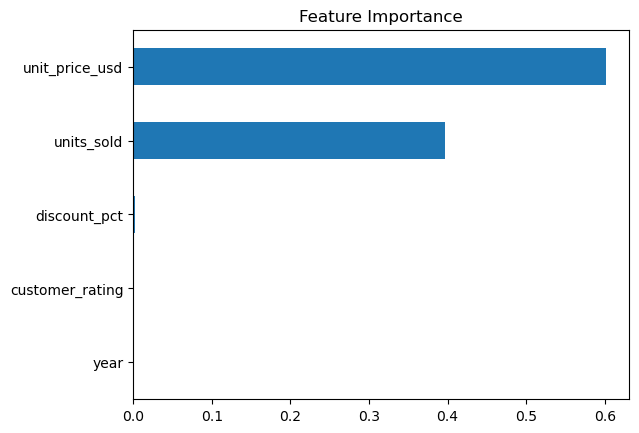

In [53]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

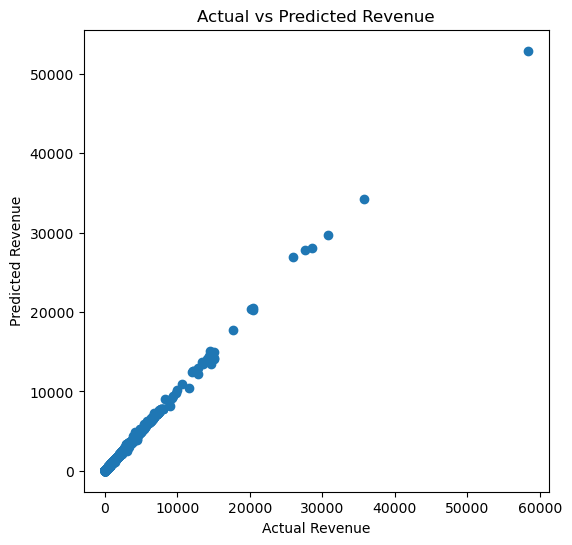

In [54]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, rf_pred)
plt.xlabel("Actual Revenue")
plt.ylabel("Predicted Revenue")
plt.title("Actual vs Predicted Revenue")
plt.show()

In [55]:
sample = X_test.iloc[:10]
future_pred = rf.predict(sample)
future_pred

array([ 828.8219,  593.8292,  775.4465,  386.1   , 2276.2244,  965.6773,
       1840.3538,  169.4857,   39.5306,  604.7439])

In [56]:
rf.fit(X, y)

RandomForestRegressor(random_state=42)

In [ ]:
future_data = pd.DataFrame({
    'year': [2026, 2027, 2028, 2029, 2030],
    'discount_pct': [10,10,10,10,10],
    'customer_rating': [4.5,4.5,4.5,4.5,4.5],
    'unit_price_usd': [1200,1200,1200,1200,1200],
    'units_sold': [5,5,5,5,5]
})

In [5]:
future_predictions = rf.predict(future_data)

print(future_predictions)

NotFittedError: This RandomForestRegressor instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
plt.plot(future_data['year'], future_data['Predicted_Revenue'], marker='o')
plt.title("Revenue Forecast for Next 5 Years")
plt.xlabel("Year")
plt.ylabel("Predicted Revenue")
plt.show()